# Ice speed trends in west Greenland (advanced)

In this example, we move beyond basic data extraction and compute temporal statistics (such as the linear trend in ice speed and its statistical significance (p-value)) on a pixel-by-pixel basis. Analyzing these time-series allows us to identify where glaciers are actively accelerating or slowing down, which is critical for understanding broader ice sheet dynamics.

While we will focus on a moderately sized area in West Greenland, which has been the focus of many investigations, to ensure this notebook runs relatively quickly. The workflow is explicitly designed to scale up, where sufficient resources are available.

### Managing the workload with Dask
Time-series analysis on large multidimensional datasets (like our Zarr stores) can be computationally expensive. I certainly could not load the entire dataset into memory at once on my PC. To enable analysis of arrays that do not fit into memory, we use **Dask**, which also supports parallel computation.

First, we will load our core dependencies and initialize a LocalCluster. Here is what is happening under the hood:
* `xarray` & `rioxarray`: For lazily loading and managing the geospatial data cube.
* `scipy.stats` & `numpy`: For performing the maths.
* `pyproj`: To handle spatial coordinate transformations.
* `LocalCluster`: This automatically inspects the machine running the notebook, creates a pool of "workers" based on the available CPU cores, and actively manages memory limits so we don't overflow the RAM.

> _Tip: If you run the cell below, an HTML representation of the `client` will appear. Clicking the **Dashboard link** opens a new tab where you can watch Dask distribute the tasks across your CPU cores in real-time_

By default, Dask tries to maximise throughout by requesting many Zarr chunks simultaneously. Over plain HTTP, this can overwhelm local TCP socket limits and router state tables, causing dropped packets and truncated downloads mid-stream, which would end the computation. Depending on your connection, it can be necessary to limit the number of total worker execution threads, cap the number of open sockets and limit how many asynchronous chunks each thread can request at once. 

In [1]:
import warnings
import numpy as np
import xarray as xr
import rioxarray
import geopandas as gpd
import shapely.geometry
import scipy.stats
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource
from pyproj import Transformer
from dask.distributed import Client, LocalCluster
import dask
import zarr
import aiohttp

# Spin up a local Dask cluster, limiting the number of workers and the number of threads per work
cluster = LocalCluster(n_workers=4, threads_per_worker=2)
client = Client(cluster)

# 1. Cap Zarr's internal HTTP concurrency per worker
zarr.config.set({"async.concurrency": 2})

# Configure the HTTP backend to allow more time for large chunks
s3_options = {
    "anon": True, 
    "config_kwargs": {
        "max_pool_connections": 50,  
        "retries": {
            "max_attempts": 10,      
            "mode": "standard"       
        }
    }
}

# Display the dashboard link so users can watch the processing graph
print(f"Dask Dashboard: {client.dashboard_link}")

C:\Users\gg1bjd\AppData\Local\anaconda3\envs\shiver_env\Lib\site-packages\distributed\node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 52182 instead
  warnings.warn(


Dask Dashboard: http://127.0.0.1:52182/status


## Define function to calculate temporal statistics
Next, we need to define the mathematical operations we want to perform on our velocity data. We will extract four key metrics for every single pixel:
* **Time-average mean speed**
* **Measurement count:** The number of valid (non-NaN) observations over time, which helps us gauge the reliability of the trend.
* **Linear trend** The rate of change in speed over time (acceleration or deceleration).
* **Significance (p-value):** The statistical confidence that the observed trend is real and not just random noise.

### Why write a custom, pure-NumPy function?
If you look closely at the code below, you will notice we calculate the linear regression (slope and p-value) manually using sums of squares (`numerator`, `denominator`, `ss_res`), rather than using a built-in tool like `scipy.stats.linregress`.

There are two major reasons for this design choice:
1. **Multi-dimensional vectorization:** Standard functions like `scipy.stats.linregress` are designed to work on 1D arrays (a single pixel at a time). If we used a for loop to apply a 1D function across this many spatial pixels, it would take a little too long for this example. By writing the math out using NumPy primitives and specifying `axis=-1` (the time dimension), we evaluate the trend for an entire 3D block of data (y, x, time) simultaneously at C-level speed.
2. **Missing data handling:** Ice velocity fields derived from satellite imagery always suffers from some data gaps. By using `np.nanmean` and `np.nansum`, our manual regression ignores these missing data slices without throwing errors. Of course, this means we are actually calculating a trend through varying numbers of data points and varying time periods in each pixel. To make this analysis robust, we would need to identify which pixels had sufficient data that was sufficiently spread over the time period of interest to calculate a representative trend. However, since this is just an example to illustrate the process, we will skip those important details here and we'll approximate the areas with _good_ data using the p-value.

In [2]:
def _calc_stats_numpy(y, t):
    """
    Pure NumPy function to calculate stats along the last axis (-1).
    y shape: (..., time), t shape: (time,)
    """
    y = y.astype(float)
    t = t.astype(float)

    valid = ~np.isnan(y)
    count = np.sum(valid, axis=-1)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        
        # 1. Mean
        mean = np.nanmean(y, axis=-1)

        # 2. Linear Trend (Slope)
        t_masked = np.where(valid, t, np.nan)
        t_mean = np.nanmean(t_masked, axis=-1)

        t_anom = t_masked - t_mean[..., np.newaxis]
        y_anom = y - mean[..., np.newaxis]

        numerator = np.nansum(t_anom * y_anom, axis=-1)
        denominator = np.nansum(t_anom ** 2, axis=-1)

        slope = np.where((count >= 2) & (denominator != 0), numerator / denominator, np.nan)

        # 3. P-Value
        y_pred_anom = slope[..., np.newaxis] * t_anom
        residuals = y_anom - y_pred_anom
        ss_res = np.nansum(residuals ** 2, axis=-1)

        df = count - 2
        se_sq = np.where(df > 0, (ss_res / df) / denominator, np.nan)
        se = np.sqrt(se_sq)

        t_stat = np.where(se > 0, slope / se, np.nan)
        p_val = 2 * scipy.stats.t.sf(np.abs(t_stat), df)
        p_val = np.where(count >= 3, p_val, np.nan)

    return mean, count, slope, p_val

## Connecting to the Cloud and subsetting the data
Now we will connect to our dataset and isolate the region we want to analyze. If you have sufficient computational resources, you could skip the subsetting step and process the entire ice sheet, but for this example, we will focus on this area in west Greenland.

> _Note: Lazy Loading from the Cloud: We are pointing `xarray` directly to a URL hosted on Source Cooperative. Because Zarr is a cloud-optimized format, `xr.open_zarr` reads only the dataset's metadata (the `consolidated=True` flag makes this very fast). No actual velocity data is downloaded until we trigger the Dask computation later._

In previous examples, we used the standard `https://` path for the Zarr store. In this example, we will use the `s3://` path. We do this because the S3 protocol is backed by `botocore` (AWS's official C/Python engine), which includes build-in socket keep-alives and retry algorithms specifically designed for object storage I/O. Generic HTTP clients (like `aiohttp`) lack this architecture and fail immediately upon encountering network hiccups. `s3fs` is also preferable to plain HTTP access via `fsspec` because the former manages its background event loops in isolated threads, which prevents conflicts with Jupyter's internal `asyncio` event loop. The last reason why S3 is better here is that the AWS S3 APIs (used by `s3fs`) are optimised for chunked binary arrays, reducing overheads compared to file streaming over HTTPS.

In [3]:
# 1. Define paths and parameters
#zarr_path = "https://data.source.coop/uos-shiver/greenland/greenland_multisource_velocity_timeseries.zarr"
zarr_path = "s3://us-west-2.opendata.source.coop/uos-shiver/greenland/greenland_multisource_velocity_timeseries.zarr"
bed_path = r"/no/one/wants/to/see/my/directory/structure/BedMachineGreenland-v5.nc"

source = "AllSources"

# 2. Define region of interest in Lat/Lon 
min_lon, max_lon = -51.548, -45.940 
min_lat, max_lat = 64.991, 68.629
# Or use a smaller area for quicker testing
#min_lon, max_lon = -50.4383, -48.6306
#min_lat, max_lat = 66.6818, 67.2586

print("Opening Zarr store...")
ds = xr.open_zarr(zarr_path, consolidated=True, storage_options=s3_options)

if source.lower() != "allsources":
    source_mask = (ds['data_source'] == source).compute()
    ds = ds.isel(time=source_mask)

# 3. Convert Lat/Lon bounding box to EPSG:3413
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3413", always_xy=True)
lons = [min_lon, max_lon, max_lon, min_lon]
lats = [min_lat, min_lat, max_lat, max_lat]
xs, ys = transformer.transform(lons, lats)
min_x, max_x = min(xs), max(xs)
min_y, max_y = min(ys), max(ys)

x_slice = slice(min_x, max_x) if ds.x[0] < ds.x[-1] else slice(max_x, min_x)
y_slice = slice(min_y, max_y) if ds.y[0] < ds.y[-1] else slice(max_y, min_y)

ds_sub = ds.sel(x=x_slice, y=y_slice)


Opening Zarr store...


## Computing metrics using Dask

Now that we have subsetted our dataset to a manageable region, it is time to calculate our statistics: mean speed, measurement count, linear trend, and the trend's p-value.

To do this efficiently, we use a combination of **Dask** for parallelization and `xarray.apply_ufunc` to execute our custom math.

### How it works
1. **Prepare the Data:** We first calculate time in decimal years to ensure our trend (slope) is returned in physical units ($m/yr^2$). We then ensure our core dimension (time) is in a single contiguous chunk using `.chunk({'time': -1})`.
2. **Apply the Universal Function:** `xr.apply_ufunc` acts as a bridge. It unwraps our Xarray DataArrays, passes the raw, chunked underlying Dask arrays to our pure NumPy function (_calc_stats_numpy) and then re-wraps the results back into Xarray objects with all coordinates and metadata intact.
3. **Compute:** By setting `dask="parallelized"`, Dask knows to map our NumPy function across all spatial chunks independently. The math happens instantly at the C-level inside NumPy on a per-chunk basis.

### Why use `xr.apply_ufunc`
For complex calculations like regressions and p-values, `apply_ufunc` is highly beneficial:
* **Prevents Graph Bloat:** If you try to write complex multi-step math (like calculating residuals, standard errors, and T-statistics) using native `Xarray`/`Dask` operations, `Dask` creates an individual task in its graph for every single mathematical operation. This can result in task graphs with millions of nodes, which crashes the Dask scheduler before the computation even begins.
* **Access to SciPy/NumPy Ecosystems:** It allows us to use highly optimized functions like `scipy.stats.t.sf` (for p-values) that do not have direct equivalents in native `Dask`.
* **Speed:** Stripping away the `Xarray` metadata during the actual computation loop reduces overhead, running much faster on raw numpy arrays.

### What are the alternatives
Depending on your use case, there are other ways to compute statistics on gridded data:
* **Native Xarray/Dask Methods** (e.g., `ds.mean(dim='time')` or `ds.polyfit()`)
    - _When to use it:_ For simple aggregations (mean, max, standard deviation) or basic polynomial fits. It is built-in, easy to read, and handles missing data automatically.
    - _Why we didn''t use it:_ Xarray's `polyfit` does not return p-values, and building the p-value math natively causes the graph bloat mentioned above.
* `xarray.Dataset.map_blocks`
    - _When to use it:_ When your custom function needs to interact with Xarray coordinates or metadata inside the function, rather than just the raw numbers.
    - _Why we didn't use it:_ It passes whole Xarray datasets into the function chunk-by-chunk, which introduces more overhead than `apply_ufunc` passing bare numpy arrays.
* `dask.array.map_blocks`
    - _When to use it:_ When you are working purely with Dask arrays and don't care about spatial coordinates.
    - _Why we didn't use it:_ `apply_ufunc` is essentially a wrapper around map_blocks that does the heavy lifting of aligning dimensions and preserving Xarray coordinates for us.

In [4]:
# 5. Define Time Periods
periods = {
    '2003_2013': ('2003-01-01', '2013-01-31'),
    '2014_2020': ('2014-03-01', '2020-03-31'),
    '2019_2025': ('2019-03-01', '2025-03-31')
}

period_labels = {
    '2003_2013': 'Jan 2003 to Jan 2013',
    '2014_2020': 'March 2014 to March 2020',
    '2019_2025': 'March 2019 to March 2025'
}

results = {}

print("Building task graphs for all periods...")
for period_name, (start, end) in periods.items():
    # Subset time period
    ds_period = ds_sub.sel(time=slice(start, end))
    num_epochs = len(ds_period['time'])
    
    t_years = ds_period['time'].dt.year + (ds_period['time'].dt.dayofyear / 365.25)
    
    # Pass directly to apply_ufunc
    mean_da, count_da, slope_da, p_val_da = xr.apply_ufunc(
        _calc_stats_numpy,
        ds_period['speed'],
        t_years,
        input_core_dims=[['time'], ['time']],
        output_core_dims=[[], [], [], []],
        vectorize=False,
        dask="parallelized",
        output_dtypes=[np.float64, np.int32, np.float64, np.float64]
    )
    
    results[period_name] = {
        'num_epochs': num_epochs,
        'mean': mean_da,
        'count': count_da,
        'slope': slope_da,
        'p_val': p_val_da
    }

print("Computing metrics via Dask... (Check dashboard for progress)")


Building task graphs for all periods...
Computing metrics via Dask... (Check dashboard)


Now that we have computed grids of trends in suitable locations, we should mask the data so that we only plot the output where it makes sense to do so:

In [5]:
print("Computation complete! Applying masks...")

# Load BedMachine and align to our subset grid using nearest neighbor
bed_path = r"/no/one/wants/to/see/my/directory/structure/BedMachineGreenland-v5.nc"
bed_ds = xr.open_dataset(bed_path)
bed_mask = bed_ds['mask'].interp(x=ds_sub.x, y=ds_sub.y, method='nearest').compute()

print("Computing metrics period by period...")
final_masked_trends = {}

# 3. Compute each period sequentially 
for period_name, p_data in results.items():
    print(f"Computing {period_name}...")
    
    mean_c, count_c, slope_c, p_val_c = dask.compute(
        p_data['mean'], p_data['count'], p_data['slope'], p_data['p_val']
    )
    
    num_epochs = p_data['num_epochs']
    
    # Apply masking
    valid_mask = (p_val_c < 0.15) & (bed_mask == 2)
    final_masked_trends[period_name] = slope_c.where(valid_mask)

Computation complete! Applying masks...
Computing metrics period by period...
Computing 2003_2013...
Computing 2014_2020...
Computing 2019_2025...


Next, prepare some auxilliary data for plotting:

In [6]:
dem_path = r"/no/one/wants/to/see/my/directory/structure/gimpdem_90m_v01.1.tif"
shp_path = r"/no/one/wants/to/see/my/directory/structure/01-PROMICE-2022-IceMask-line-v3_latlon.shp"

print("Loading DEM and preparing hillshade/contours...")
# Load DEM and clip
dem = rioxarray.open_rasterio(dem_path).squeeze()
dem = dem.rio.clip_box(minx=min_x, miny=min_y, maxx=max_x, maxy=max_y)

# Interpolate BedMachine mask to match the DEM grid resolution
bed_mask_dem = bed_ds['mask'].interp(x=dem.x, y=dem.y, method='nearest').compute()

# Create an on-ice DEM, to make contours
dem_masked_for_contours = dem.where((dem > -9000) & (bed_mask_dem == 2))

# Create a DEM for the background hillshade
dem_base = dem.where(dem > -9000, np.nan)

print("Loading and clipping vector shapefile...")
ice_mask = gpd.read_file(shp_path)
ice_mask_3413 = ice_mask.to_crs(epsg=3413)
bbox_polygon = shapely.geometry.box(min_x, min_y, max_x, max_y)
ice_mask_clipped = ice_mask_3413.clip(bbox_polygon)

Loading DEM and preparing hillshade/contours...
Loading and clipping vector shapefile...


Finally, plot the data:

Generating publication-quality figure...


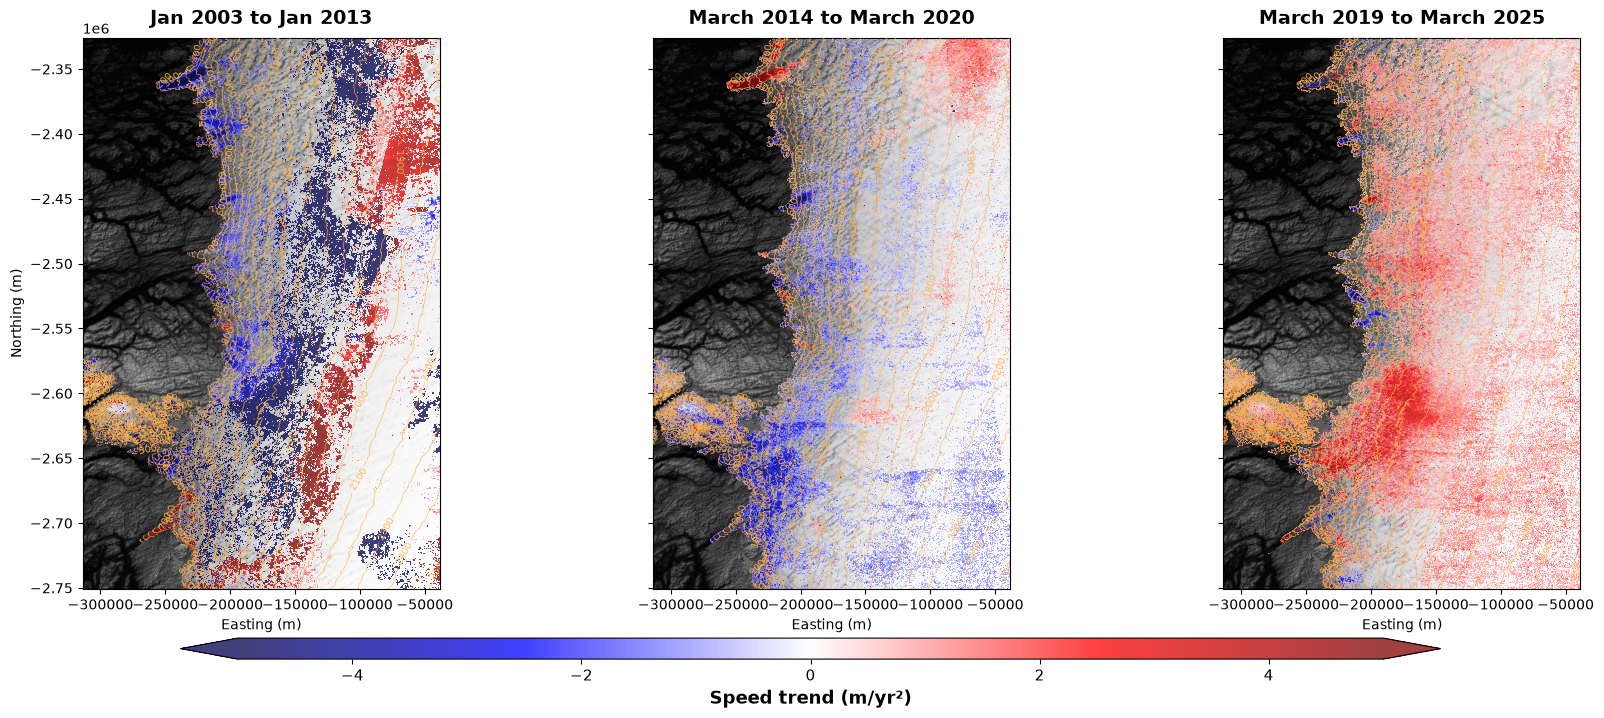

In [7]:
print("Generating publication-quality figure...")
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharex=True, sharey=True)

# Hillshade using base DEM
ls = LightSource(azdeg=315, altdeg=45)
dem_filled = np.nan_to_num(dem_base.values, nan=0.0)
shaded_dem = ls.shade(dem_filled, cmap=plt.cm.gray, blend_mode='soft', vert_exag=1.5)

# Convert extent values to standard scalars for matplotlib
dem_extent = [
    dem_base.x.min().item(), dem_base.x.max().item(), 
    dem_base.y.min().item(), dem_base.y.max().item()
]

for i, (ax, (period_name, trend_data)) in enumerate(zip(axes, final_masked_trends.items())):
    # a. Plot DEM Hillshade
    ax.imshow(shaded_dem, extent=dem_extent, origin='upper', zorder=1)
    
    # b. Overlay the computed trend 
    im = trend_data.plot(
        ax=ax, cmap='seismic', vmin=-5, vmax=5, 
        add_colorbar=False, alpha=0.75, zorder=2
    )
    
    # c. Plot DEM contours
    levels = np.arange(0, int(np.nanmax(dem_masked_for_contours.values)) + 100, 100)
    cs = ax.contour(dem_masked_for_contours.x, dem_masked_for_contours.y, dem_masked_for_contours.values, 
                    levels=levels, colors='#FFB347', linewidths=0.5, alpha=0.8, zorder=3)
    ax.clabel(cs, inline=True, fontsize=7, fmt='%d', colors='#FFB347')
    
    # d. Plot ice edge
    ice_mask_clipped.plot(ax=ax, color='none', edgecolor='black', linewidth=1.5, zorder=4)
    
    # e. make it pretty
    ax.set_title(period_labels[period_name], fontsize=14, fontweight='bold', pad=10)
    ax.set_aspect('equal')
    ax.set_xlabel('Easting (m)')
    
    if i == 0:
        ax.set_ylabel('Northing (m)')
    else:
        ax.set_ylabel('')

plt.tight_layout()

# Add unified colorbar
cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.03])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal', extend='both')
cbar.set_label('Speed trend (m/yr²)', fontsize=13, fontweight='bold')
cbar.ax.tick_params(labelsize=11)

plt.subplots_adjust(bottom=0.15) 
plt.show()

Which is neat because it broadly agrees with the results of Tedstone et al. (2015) and Williams et al. (2020), showing a long-term deceleration of ice in some parts of the ablation zome of this land-terminating sector of west Greenland until around 2020, followed by a period of acceleration across the same area. 

In [8]:
client.close()
cluster.close()